Regression Model Python - 4/12/26 - derave1577

In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from datetime import datetime
from IPython.display import display, Markdown

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "derave1577"

california_housing = fetch_california_housing(as_frame=True)
data = california_housing.frame

display(Markdown("### Step 1.2: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
display(data.head())

### Step 1.2: Load the Dataset

Date: 2026-04-12

Student ID: derave1577

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
display(Markdown("### Step 1.3: Initial Exploration of the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

print(data.info())

display(data.describe())

### Step 1.3: Initial Exploration of the Dataset

Date: 2026-04-12

Student ID: derave1577

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
display(Markdown("### Step 1.4: Data Cleaning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

missing_values = data.isnull().sum()
print(f"Missing values in each column:\n{missing_values}")

for column in data.select_dtypes(include=['number']).columns:
    data[column].fillna(data[column].median(), inplace=True)

### Step 1.4: Data Cleaning

Date: 2026-04-12

Student ID: derave1577

Missing values in each column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


C:\Users\Derek A\AppData\Local\Temp\ipykernel_22172\1692120862.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data[column].fillna(data[column].median(), inplace=True)
C:\Users\Derek A\AppData\Local\Temp\ipykernel_22172\1692120862.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

In [6]:
display(Markdown("### Step 1.5: Feature Selection"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

selected_features = data.drop(columns=['MedHouseVal'])
target = data['MedHouseVal']

display(selected_features.head())

### Step 1.5: Feature Selection

Date: 2026-04-12

Student ID: derave1577

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [7]:
display(Markdown("### Step 2.1: Data Splitting"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.model_selection import train_test_split

X = selected_features
y = target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

### Step 2.1: Data Splitting

Date: 2026-04-12

Student ID: derave1577

Training set size: 16512 samples
Test set size: 4128 samples


In [8]:
display(Markdown("### Step 2.2: Model Training"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

print("Model training completed.")

### Step 2.2: Model Training

Date: 2026-04-12

Student ID: derave1577

Model training completed.


### Step 2.3: Model Evaluation

Date: 2026-04-12

Student ID: derave1577

Mean Squared Error: 0.2939973248643864
R² Score: 0.7756446042829697


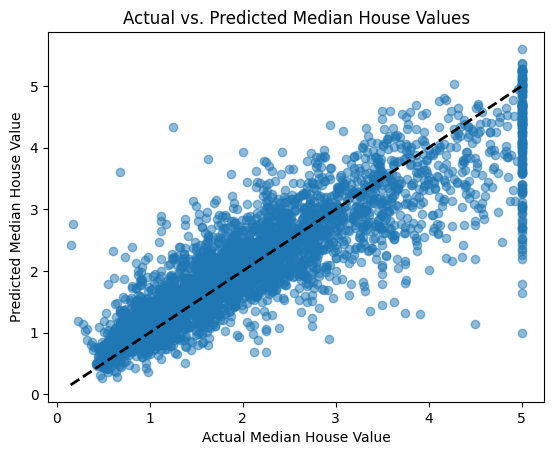

In [9]:
display(Markdown("### Step 2.3: Model Evaluation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs. Predicted Median House Values')
plt.show()

### Step 3.1: Predicting with Early Stopping

Date: 2026-04-12

Student ID: derave1577


Mean Squared Error on New Data: 0.29162405498317995
R² Score on New Data: 0.7774556952634302


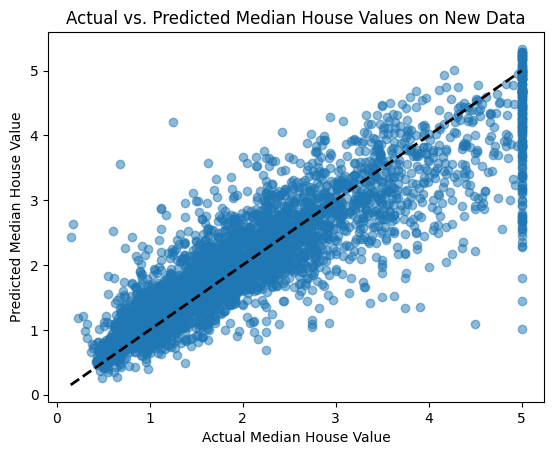

In [10]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

display(Markdown("### Step 3.1: Predicting with Early Stopping"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

model = GradientBoostingRegressor(random_state=42, n_iter_no_change=10, validation_fraction=0.1)
model.fit(X_train, y_train)

y_new_pred = model.predict(X_test)

mse_new = mean_squared_error(y_test, y_new_pred)
r2_new = r2_score(y_test, y_new_pred)

print(f"\nMean Squared Error on New Data: {mse_new}")
print(f"R² Score on New Data: {r2_new}")

plt.scatter(y_test, y_new_pred, alpha=0.5)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs. Predicted Median House Values on New Data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

### Step 3.2: Analyzing Residuals

Date: 2026-04-12

Student ID: derave1577

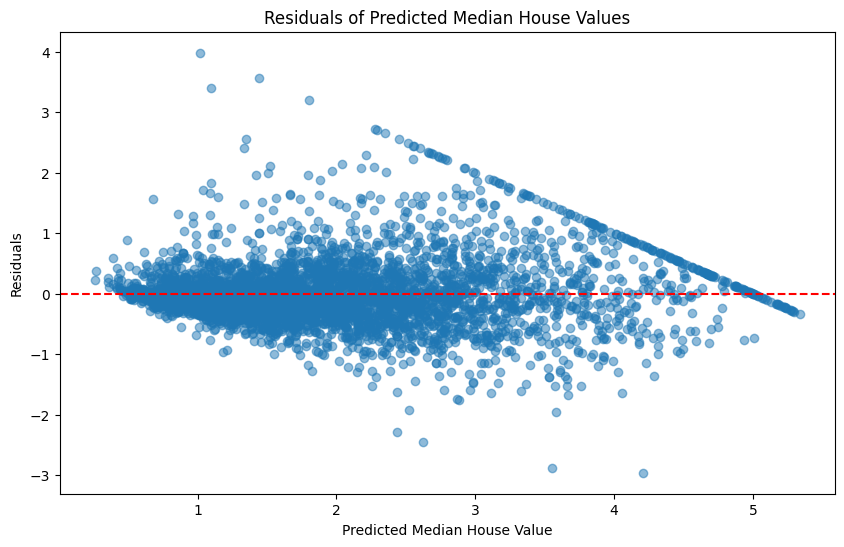

In [11]:
display(Markdown("### Step 3.2: Analyzing Residuals"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

residuals = y_test - y_new_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_new_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Median House Value')
plt.ylabel('Residuals')
plt.title('Residuals of Predicted Median House Values')
plt.show()